# Model: LDA_Dimensionality_Reduction

## Shared Setup



In [ ]:
!pip install -q datasets scikit-learn pandas matplotlib seaborn

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")
train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()

for df in (train_df, val_df, test_df):
    df["clean_text"] = df["text"].apply(clean_text)

print("Train:", train_df.shape, "| Validation:", val_df.shape, "| Test:", test_df.shape)

README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

train.parquet: reconstructing file:   0%|          |  0.00B /  699kB            

train.parquet: downloading bytes:           |  0.00B            

validation.parquet: reconstructing file:   0%|          |  0.00B / 90.0kB            

validation.parquet: downloading bytes:           |  0.00B            

...

test.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Train: (8530, 3) | Validation: (1066, 3) | Test: (1066, 3)


## 2. Implementation

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression

def to_dense(X):
    return X.toarray()

X_train_text, y_train = train_df["clean_text"], train_df["label"]
X_val_text,   y_val   = val_df["clean_text"],   val_df["label"]
X_test_text,  y_test  = test_df["clean_text"],  test_df["label"]

# Baseline: default LDA (SVD solver, no shrinkage) on a 1,000-term vocabulary
baseline = Pipeline([
    ("vec", TfidfVectorizer(max_features=1000, ngram_range=(1, 1))),
    ("dense", FunctionTransformer(to_dense, accept_sparse=True)),
    ("lda", LinearDiscriminantAnalysis()),
])
baseline.fit(X_train_text, y_train)
print(f"Baseline (default LDA) validation accuracy: "
      f"{accuracy_score(y_val, baseline.predict(X_val_text)):.4f}")
print("Number of discriminant components produced:",
      baseline.named_steps["lda"].transform(baseline.named_steps["dense"].transform(
          baseline.named_steps["vec"].transform(X_val_text[:5]))).shape[1])

Baseline (default LDA) validation accuracy: 0.7120
Number of discriminant components produced: 1


## 3. Hyperparameter Tuning Across Varieties



In [ ]:
pipe = Pipeline([
    ("vec", TfidfVectorizer(ngram_range=(1, 1))),
    ("dense", FunctionTransformer(to_dense, accept_sparse=True)),
    ("lda", LinearDiscriminantAnalysis()),
])

param_grid = [
    {"vec__max_features": [500, 1000, 1500], "lda__solver": ["svd"]},
    {"vec__max_features": [500, 1000, 1500], "lda__solver": ["eigen"], "lda__shrinkage": ["auto", 0.7, 0.8, 0.9]},
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1, return_train_score=True)
grid.fit(X_train_text, y_train)

def describe(p):
    if p["lda__solver"] == "svd":
        return "svd, no shrinkage"
    return f"eigen, shrinkage={p['lda__shrinkage']}"

results_df = pd.DataFrame({
    "max_features": [p["vec__max_features"] for p in grid.cv_results_["params"]],
    "covariance_handling": [describe(p) for p in grid.cv_results_["params"]],
    "cv_accuracy": grid.cv_results_["mean_test_score"],
    "train_accuracy": grid.cv_results_["mean_train_score"],
    "params": grid.cv_results_["params"],
}).sort_values("cv_accuracy", ascending=False).reset_index(drop=True)
results_df["cv_train_gap"] = results_df["train_accuracy"] - results_df["cv_accuracy"]

# ---- Selection rule: best CV accuracy among varieties whose overfitting gap is acceptable ----
MAX_GAP = 0.05          # <-- the maximum train-vs-CV gap we accept (8 percentage points)

unconstrained = results_df.iloc[0]                       # highest CV accuracy, ignoring overfitting
eligible = results_df[results_df["cv_train_gap"] < MAX_GAP]
selected = eligible.iloc[0] if len(eligible) else results_df.sort_values("cv_train_gap").iloc[0]

print(f"Highest CV accuracy overall (not used): max_features={unconstrained['max_features']}, "
      f"{unconstrained['covariance_handling']} -> CV {unconstrained['cv_accuracy']:.4f}, "
      f"gap {unconstrained['cv_train_gap']*100:.1f} pp")
print(f"SELECTED (best CV accuracy with gap < {MAX_GAP*100:.0f} pp): max_features={selected['max_features']}, "
      f"{selected['covariance_handling']} -> CV {selected['cv_accuracy']:.4f}, gap {selected['cv_train_gap']*100:.1f} pp")
results_df.drop(columns="params")

Highest CV accuracy overall (not used): max_features=1500, eigen, shrinkage=0.7 -> CV 0.7321, gap 6.2 pp
SELECTED (best CV accuracy with gap < 5 pp): max_features=1000, eigen, shrinkage=0.7 -> CV 0.7189, gap 4.7 pp


,max_features,covariance_handling,cv_accuracy,train_accuracy,cv_train_gap
0,1500,"eigen, shrinkage=0.7",0.732122,0.794197,0.062075
1,1500,"eigen, shrinkage=auto",0.726964,0.790563,0.063599
2,1500,"eigen, shrinkage=0.8",0.724150,0.777169,0.053019
3,1000,"svd, no shrinkage",0.721688,0.802638,0.080950
4,1000,"eigen, shrinkage=0.7",0.718875,0.765944,0.047069
5,1500,"svd, no shrinkage",0.718523,0.843435,0.124912
6,1000,"eigen, shrinkage=auto",0.717702,0.769109,0.051407
7,1500,"eigen, shrinkage=0.9",0.710551,0.755275,0.044725
8,1000,"eigen, shrinkage=0.8",0.710082,0.752374,0.042292
9,1000,"eigen, shrinkage=0.9",0.697069,0.732122,0.035053


## 4. Evaluation


In [ ]:
# Refit the SELECTED variety on the full training set
from sklearn.base import clone
best_model = clone(pipe).set_params(**selected["params"]).fit(X_train_text, y_train)

val_pred  = best_model.predict(X_val_text)
test_pred = best_model.predict(X_test_text)

print(f"Validation accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Test accuracy:       {accuracy_score(y_test, test_pred):.4f}")
print(f"Test F1 (weighted):  {f1_score(y_test, test_pred, average='weighted'):.4f}")
print()
print(classification_report(y_test, test_pred, target_names=["Negative", "Positive"]))

Validation accuracy: 0.7017
Test accuracy:       0.7214
Test F1 (weighted):  0.7213

              precision    recall  f1-score   support

    Negative       0.71      0.74      0.73       533
    Positive       0.73      0.71      0.72       533

    accuracy                           0.72      1066
   macro avg       0.72      0.72      0.72      1066
weighted avg       0.72      0.72      0.72      1066



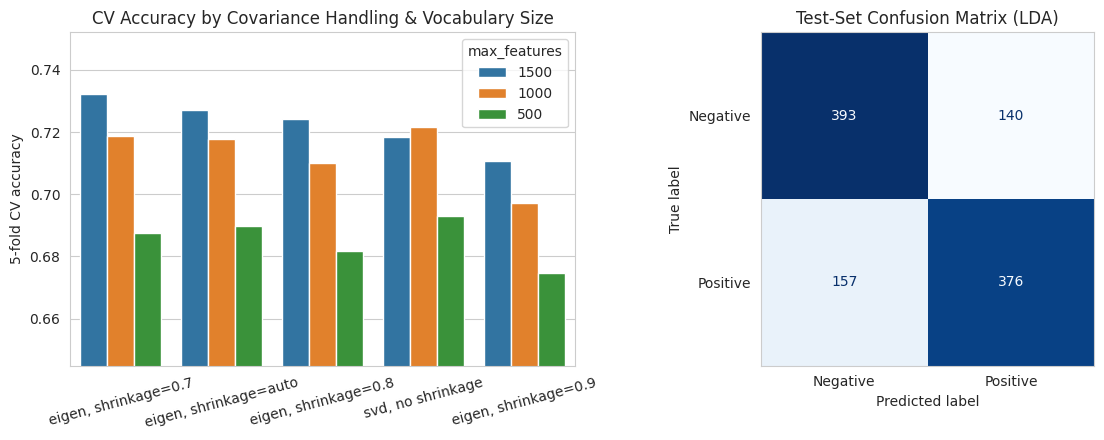

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plot_df = results_df.copy()
plot_df["max_features"] = plot_df["max_features"].astype(str)
sns.barplot(data=plot_df, x="covariance_handling", y="cv_accuracy", hue="max_features", ax=axes[0])
axes[0].set_ylim(plot_df["cv_accuracy"].min() - 0.03, plot_df["cv_accuracy"].max() + 0.02)
axes[0].set_title("CV Accuracy by Covariance Handling & Vocabulary Size")
axes[0].set_xlabel("")
axes[0].set_ylabel("5-fold CV accuracy")
axes[0].tick_params(axis="x", rotation=15)

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Test-Set Confusion Matrix (LDA)")
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 5. Visualization (2 Components)

Projected test data shape: (1066, 1) (1 discriminant component, as expected for 2 classes)


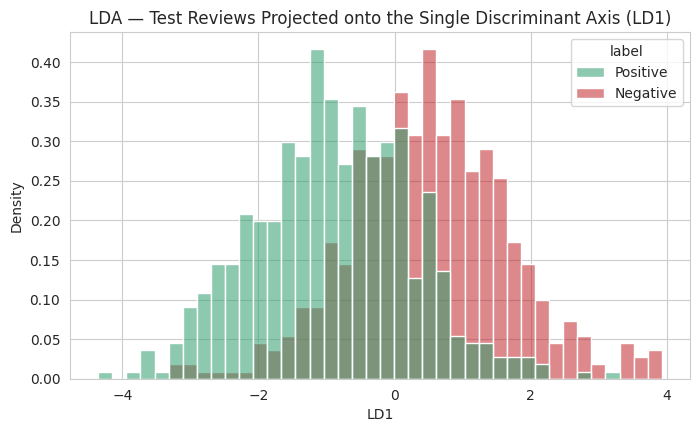

Requesting n_components=2 is rejected, as the theory predicts:
  n_components cannot be larger than min(n_features, n_classes - 1).


In [ ]:
vec_best   = best_model.named_steps["vec"]
dense_best = best_model.named_steps["dense"]
lda_best   = best_model.named_steps["lda"]

Z_test = lda_best.transform(dense_best.transform(vec_best.transform(X_test_text)))
print("Projected test data shape:", Z_test.shape, "(1 discriminant component, as expected for 2 classes)")

viz_df = pd.DataFrame({"LD1": Z_test[:, 0], "label": y_test.map({0: "Negative", 1: "Positive"}).values})
plt.figure(figsize=(8, 4.5))
sns.histplot(data=viz_df, x="LD1", hue="label", bins=40, stat="density", common_norm=False, alpha=0.55,
             palette={"Negative": "#C1272D", "Positive": "#2E9E6D"})
plt.title("LDA — Test Reviews Projected onto the Single Discriminant Axis (LD1)")
plt.show()

# Why only one component? scikit-learn enforces the min(n_features, n_classes - 1) limit.
try:
    LinearDiscriminantAnalysis(n_components=2).fit(
        dense_best.transform(vec_best.transform(X_train_text)), y_train)
except ValueError as e:
    print("Requesting n_components=2 is rejected, as the theory predicts:")
    print(" ", str(e)[:200])

In [ ]:
X_tr = dense_best.transform(vec_best.transform(X_train_text))
X_te = dense_best.transform(vec_best.transform(X_test_text))

svd1 = TruncatedSVD(n_components=1, random_state=42).fit(X_tr)
lda1 = lda_best

rows = []
for name, reducer in [("Unsupervised (TruncatedSVD, 1 comp)", svd1), ("Supervised (LDA, 1 comp)", lda1)]:
    Ztr, Zte = reducer.transform(X_tr), reducer.transform(X_te)
    clf = LogisticRegression(max_iter=1000).fit(Ztr, y_train)
    rows.append({"1-D reduction": name,
                 "train_accuracy": accuracy_score(y_train, clf.predict(Ztr)),
                 "test_accuracy": accuracy_score(y_test, clf.predict(Zte))})
pd.DataFrame(rows)

,1-D reduction,train_accuracy,test_accuracy
0,"Unsupervised (TruncatedSVD, 1 comp)",0.506096,0.506567
1,"Supervised (LDA, 1 comp)",0.759906,0.720450


## Overfitting Check: Train vs. Test Performance

In [ ]:
train_acc = accuracy_score(y_train, best_model.predict(X_train_text))
test_acc  = accuracy_score(y_test, test_pred)
gap = train_acc - test_acc

print(f"Selected settings: {selected['params']}")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Train-test gap: {gap:.4f}  ({gap*100:.1f} percentage points)")

if gap > 0.10:
    print("Gap exceeds 10 points -- likely overfitting. Increase shrinkage or reduce max_features.")
elif gap > 0.05:
    print("Moderate gap (5-10 points) -- some overfitting; worth monitoring.")
else:
    print("Gap is small -- no strong evidence of overfitting.")

print()
print("Overfitting by variety (largest and smallest CV-train gap):")
print(results_df.sort_values("cv_train_gap")[["max_features", "covariance_handling", "cv_accuracy", "cv_train_gap"]]
      .iloc[[0, -1]].to_string(index=False))

Selected settings: {'lda__shrinkage': 0.7, 'lda__solver': 'eigen', 'vec__max_features': 1000}
Train accuracy: 0.7601
Test accuracy:  0.7214
Train-test gap: 0.0388  (3.9 percentage points)
Gap is small -- no strong evidence of overfitting.

Overfitting by variety (largest and smallest CV-train gap):
 max_features  covariance_handling  cv_accuracy  cv_train_gap
          500 eigen, shrinkage=0.9     0.674795      0.021776
         1500    svd, no shrinkage     0.718523      0.124912


## 6. Comparison Across Varieties & Conclusion

In [ ]:
best_row, worst_row = selected, results_df.iloc[-1]
no_shrink = results_df[results_df["covariance_handling"] == "svd, no shrinkage"]["cv_accuracy"].max()
shrunk    = results_df[results_df["covariance_handling"] != "svd, no shrinkage"]["cv_accuracy"].max()

print(f"Varieties tried: {len(results_df)}  (CV accuracy range: {worst_row['cv_accuracy']:.4f} to {best_row['cv_accuracy']:.4f})")
print(f"Selected variety: max_features={best_row['max_features']}, {best_row['covariance_handling']}")
print(f"Best without shrinkage: {no_shrink:.4f}   |   best with shrinkage: {shrunk:.4f}")
print(f"Final test accuracy: {test_acc:.4f}   |   train-test gap: {gap*100:.1f} pp")

Varieties tried: 15  (CV accuracy range: 0.6748 to 0.7189)
Selected variety: max_features=1000, eigen, shrinkage=0.7
Best without shrinkage: 0.7217   |   best with shrinkage: 0.7321
Final test accuracy: 0.7214   |   train-test gap: 3.9 pp
